In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("/content/drive/MyDrive/Mares del Pacifico LTDA/Vueltas - Hoja 1-2.csv")

In [4]:
df.head()

,fecha,hora_llegada,hora_salida,zona,embarcacion,centro,observaciones,categoria_falla,gravedad
0,18/01/2026,7:17:00,7:23:00,melinka,costa pacifico,fresia sur,na,ok,0
1,18/01/2026,8:15:00,8:27:00,melinka,costa pacifico,guaitecas 2,na,ok,0
2,18/01/2026,9:00:00,9:17:00,melinka,costa pacifico,betecoi,na,ok,0
3,18/01/2026,11:15:00,11:32:00,melinka,costa pacifico,concoto,na,ok,0
4,18/01/2026,12:40:00,12:51:00,melinka,costa pacifico,serrano,na,ok,0


In [5]:
# Limpieza básica: quitar espacios y normalizar textos
df['embarcacion'] = df['embarcacion'].str.lower().str.strip()
df['zona'] = df['zona'].str.lower().str.strip()
df['categoria_falla'] = df['categoria_falla'].str.lower().str.strip()

# Convertir tiempos y calcular minutos de estadía real
df['fecha'] = pd.to_datetime(df['fecha'], dayfirst=True)
df['h_llegada'] = pd.to_timedelta(df['hora_llegada'])
df['h_salida'] = pd.to_timedelta(df['hora_salida'])
df['minutos_estadia'] = (df['h_salida'] - df['h_llegada']).dt.total_seconds() / 60

# Crear columna de éxito
df['es_exito'] = df['categoria_falla'] == 'ok'

print(f"Dataset listo: {len(df)} registros procesados.")

Dataset listo: 278 registros procesados.


# Dashboard desempeño por flota: Costa vs Sol

/tmp/ipykernel_10895/101083315.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='embarcacion', y='es_exito', ax=axes[0], palette='Blues_r', estimator=lambda x: sum(x)/len(x)*100)
/tmp/ipykernel_10895/101083315.py:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='embarcacion', y='minutos_estadia', ax=axes[1], palette='Oranges', ci=None)
/tmp/ipykernel_10895/101083315.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='embarcacion', y='minutos_estadia', ax=axes[1], palette='Oranges', ci=None)


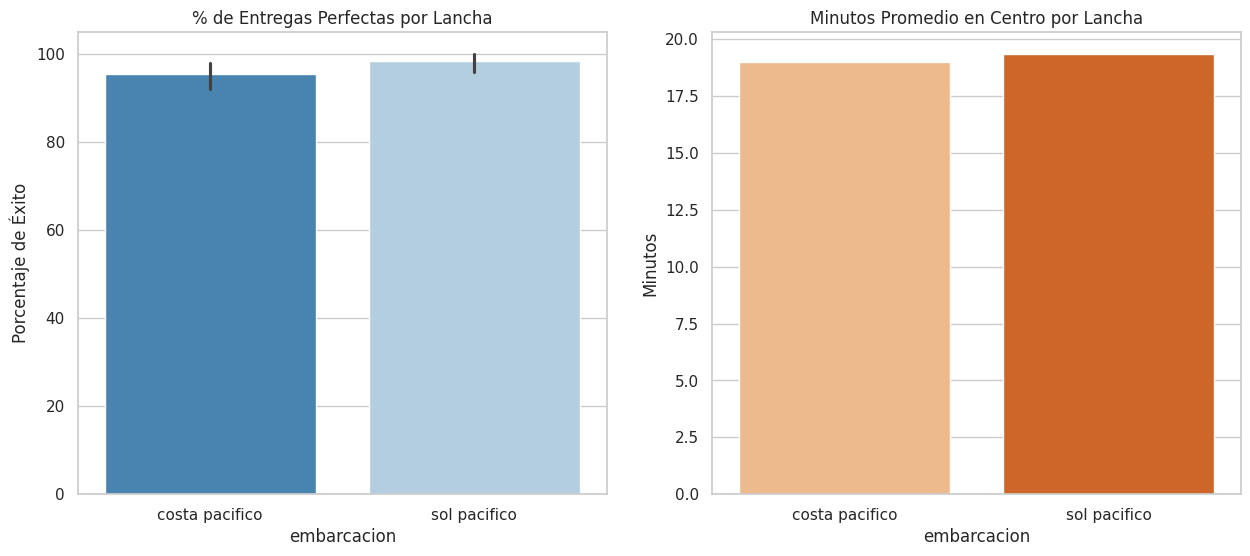

In [6]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico A: Tasa de Incidentes por Embarcación
sns.barplot(data=df, x='embarcacion', y='es_exito', ax=axes[0], palette='Blues_r', estimator=lambda x: sum(x)/len(x)*100)
axes[0].set_title('% de Entregas Perfectas por Lancha')
axes[0].set_ylabel('Porcentaje de Éxito')

# Gráfico B: Tiempo Promedio de Descarga por Lancha
sns.barplot(data=df, x='embarcacion', y='minutos_estadia', ax=axes[1], palette='Oranges', ci=None)
axes[1].set_title('Minutos Promedio en Centro por Lancha')
axes[1].set_ylabel('Minutos')

plt.show()

# Gravedad acumulada: Análisis de puntos críticos

In [7]:
# Ranking de Gravedad por Centro y Embarcación
ranking = df.groupby(['embarcacion', 'centro'])['gravedad'].sum().sort_values(ascending=False).head(10)

print("🚨 TOP 10 PUNTOS CRÍTICOS (Mayor Gravedad Acumulada):")
print(ranking)

🚨 TOP 10 PUNTOS CRÍTICOS (Mayor Gravedad Acumulada):
embarcacion     centro       
costa pacifico  benjamin         6
                isla may         4
                izaza            4
sol pacifico    pangal 2         3
costa pacifico  gertrudis 1      2
sol pacifico    pangal 3         2
costa pacifico  valverde 2       1
                base pacifico    1
                aquachile 180    0
                francisco sur    0
Name: gravedad, dtype: int64


In [8]:
def reporte_alden(df):
    lanchas = df['embarcacion'].unique()
    texto = "🚢 *REPORTE DE FLOTA ACTUALIZADO*\n"

    for lancha in lanchas:
        sub = df[df['embarcacion'] == lancha]
        exito = (sub['es_exito'].mean() * 100)
        tiempo = sub['minutos_estadia'].mean()
        texto += f"\n📍 *{lancha.upper()}*:\n"
        texto += f"   - Eficiencia: {exito:.1f}% de entregas OK\n"
        texto += f"   - Tiempo promedio: {tiempo:.1f} min por centro\n"

    incidentes = df[df['gravedad'] >= 3]
    if not incidentes.empty:
        texto += "\n⚠️ *ALERTAS (Gravedad 3+):*\n"
        for _, row in incidentes.iterrows():
            texto += f"   - {row['centro']}: {row['observaciones']}\n"

    return texto

print(reporte_alden(df))

🚢 *REPORTE DE FLOTA ACTUALIZADO*

📍 *COSTA PACIFICO*:
   - Eficiencia: 95.5% de entregas OK
   - Tiempo promedio: 19.0 min por centro

📍 *SOL PACIFICO*:
   - Eficiencia: 98.4% de entregas OK
   - Tiempo promedio: 19.3 min por centro

⚠️ *ALERTAS (Gravedad 3+):*
   - izaza: todos los congelados descongelados
   - isla may: todas las carnes descongeladas
   - benjamin: llega 01 tomate con hongos por lo cual se bota
   - benjamin: 4 huevos quebrados; 1 cebolla podrida, 1 papa podrida, 2 brocolis podridos, 3 yogurt vencidos
   - pangal 2: duraznos con hongos



# Análisis de "Fatiga de Ruta" (Fallas según el orden de entrega)

¿Suelen ocurrir más errores en la primera entrega de la mañana o en la última de la noche?

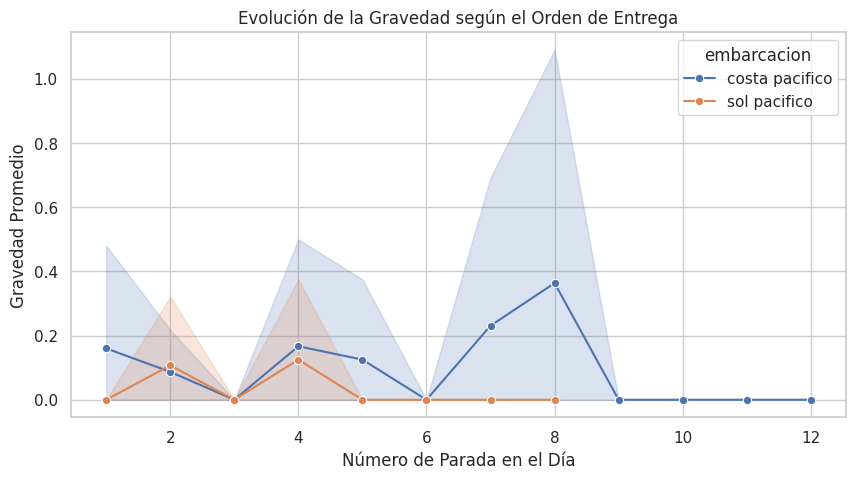

In [9]:
# Se ordena por lancha, fecha y hora para tener la secuencia real
df = df.sort_values(['embarcacion', 'fecha', 'h_llegada'])

# Se numera las paradas del día (1ra, 2da, 3ra...)
df['n_parada'] = df.groupby(['embarcacion', 'fecha']).cumcount() + 1

plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x='n_parada', y='gravedad', hue='embarcacion', marker='o')
plt.title('Evolución de la Gravedad según el Orden de Entrega')
plt.xlabel('Número de Parada en el Día')
plt.ylabel('Gravedad Promedio')
plt.show()

# Mapa de Calor: Horas Críticas

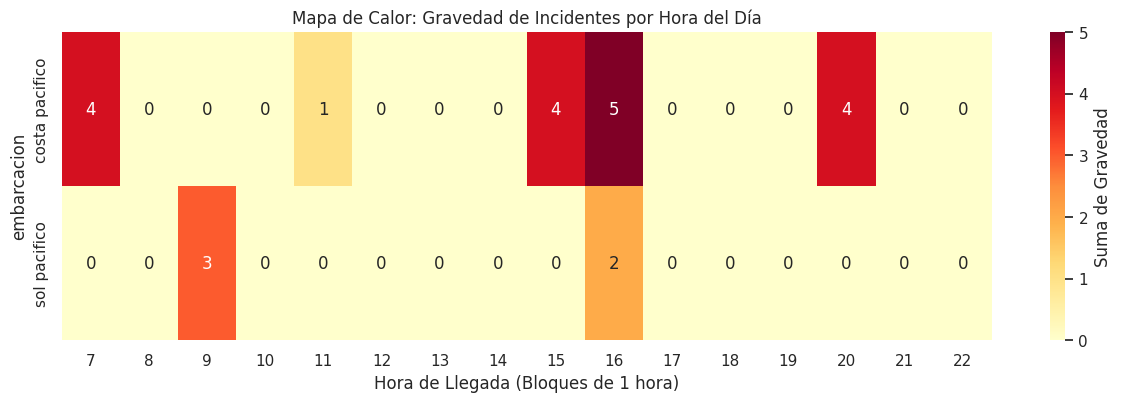

In [10]:
# Extraer la hora (0-23)
df['hora_entera'] = df['h_llegada'].dt.components.hours

# Crear una matriz para el mapa de calor
pivot_h = df.pivot_table(index='embarcacion', columns='hora_entera', values='gravedad', aggfunc='sum').fillna(0)

plt.figure(figsize=(15, 4))
sns.heatmap(pivot_h, annot=True, cmap='YlOrRd', cbar_kws={'label': 'Suma de Gravedad'})
plt.title('Mapa de Calor: Gravedad de Incidentes por Hora del Día')
plt.xlabel('Hora de Llegada (Bloques de 1 hora)')
plt.show()

# Perfil de Eficiencia por Lancha

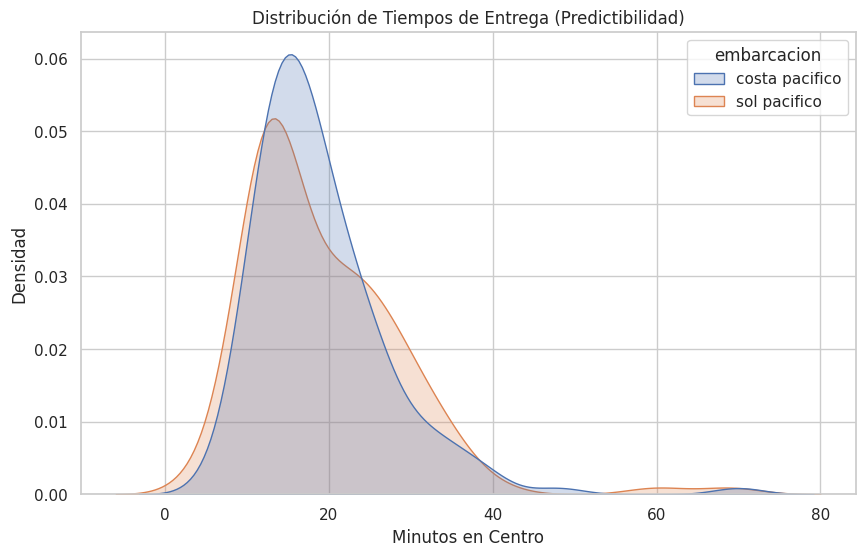

In [11]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='minutos_estadia', hue='embarcacion', fill=True, common_norm=False)
plt.title('Distribución de Tiempos de Entrega (Predictibilidad)')
plt.xlabel('Minutos en Centro')
plt.ylabel('Densidad')
plt.show()

# Predicción de gravedad

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder

In [13]:
df_ml = df.copy()

In [14]:
# 2. Convertir la hora a un número decimal (ej: 14:30 -> 14.5) para que el modelo la entienda
df_ml['hora_num'] = df['h_llegada'].dt.components.hours + df['h_llegada'].dt.components.minutes / 60

In [15]:
# 3. Codificar variables de texto a números
le_zona = LabelEncoder()
le_lancha = LabelEncoder()
le_centro = LabelEncoder()

df_ml['zona_n'] = le_zona.fit_transform(df_ml['zona'])
df_ml['lancha_n'] = le_lancha.fit_transform(df_ml['embarcacion'])
df_ml['centro_n'] = le_centro.fit_transform(df_ml['centro'])

# Definir X (lo que usamos para predecir) y y (lo que queremos predecir)
X = df_ml[['zona_n', 'lancha_n', 'centro_n', 'hora_num']]
y = df_ml['gravedad'] # Queremos predecir el nivel de 0 a 5

# Dividir en datos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenamiento del modelo

In [16]:
modelo = DecisionTreeClassifier(max_depth=3) # Limitamos la profundidad para no sobreajustar
modelo.fit(X_train, y_train)

print(f"Precisión del modelo: {modelo.score(X_test, y_test)*100:.2f}%")

Precisión del modelo: 94.64%


In [18]:
def predecir_riesgo(zona, lancha, centro, hora):
    # Transformar los datos de entrada
    z = le_zona.transform([zona.lower()])[0]
    l = le_lancha.transform([lancha.lower()])[0]
    c = le_centro.transform([centro.lower()])[0]

    prediccion = modelo.predict([[z, l, c, hora]])[0]

    # Dar una respuesta humana
    niveles = {0: "Mínimo", 1: "Muy Bajo", 2: "Bajo", 3: "Medio", 4: "Alto", 5: "Crítico"}
    return f"El riesgo estimado para esta entrega es: {niveles.get(prediccion, 'Desconocido')} (Gravedad {prediccion})"

# Ejemplo de uso
print(predecir_riesgo('puerto cisnes', 'sol pacifico', 'pangal 3', 15.0))

El riesgo estimado para esta entrega es: Mínimo (Gravedad 0)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


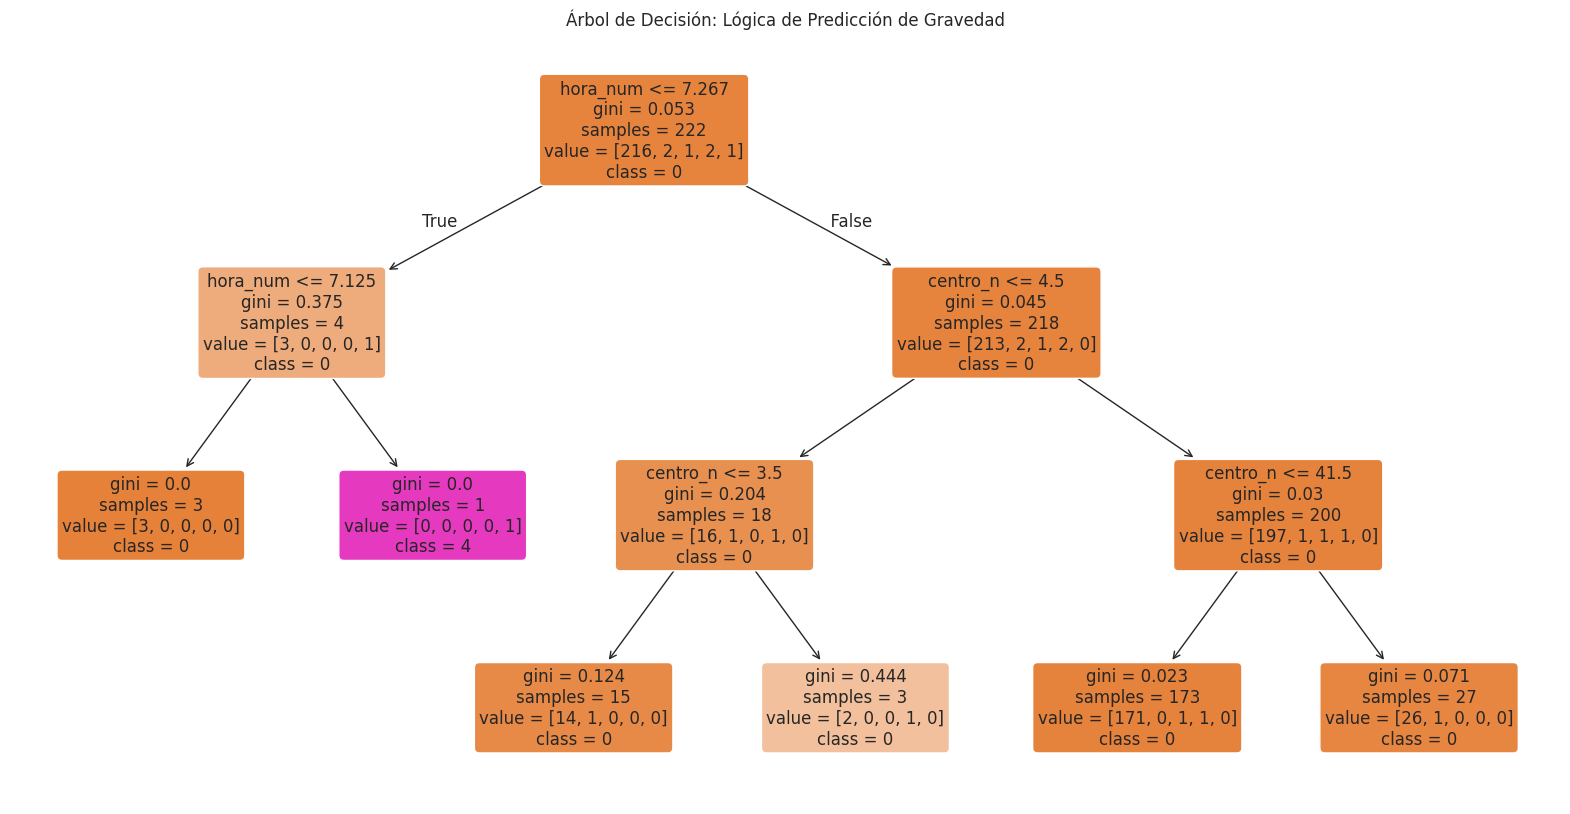

In [19]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Configuramos el tamaño de la figura
plt.figure(figsize=(20, 10))

# Graficamos el árbol
plot_tree(modelo,
          feature_names=['zona_n', 'lancha_n', 'centro_n', 'hora_num'],
          class_names=[str(i) for i in sorted(df['gravedad'].unique())],
          filled=True,
          rounded=True,
          fontsize=12)

plt.title("Árbol de Decisión: Lógica de Predicción de Gravedad")
plt.show()

# ¿Que influye mas en la gravedad de las entregas?

/tmp/ipykernel_10895/4077032285.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importancias, x='Importancia', y='Variable', palette='viridis')


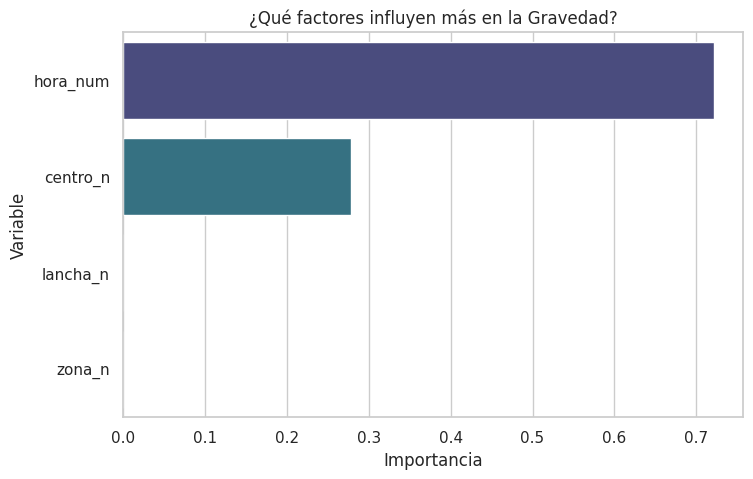

In [20]:
# Obtener la importancia de cada característica
importancias = pd.DataFrame({'Variable': X.columns, 'Importancia': modelo.feature_importances_})
importancias = importancias.sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=importancias, x='Importancia', y='Variable', palette='viridis')
plt.title('¿Qué factores influyen más en la Gravedad?')
plt.show()

# Mejorando la precisión del modelo

Se agrega día de la semana como variable numerica

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder

# 1. Crear copia y extraer el día
df_ml = df.copy()
df_ml['dia_semana'] = df_ml['fecha'].dt.dayofweek  # Lunes=0, Domingo=6

# 2. Convertir la hora a número decimal
df_ml['hora_num'] = df_ml['h_llegada'].dt.components.hours + df_ml['h_llegada'].dt.components.minutes / 60

# 3. Codificar variables de texto
le_zona = LabelEncoder()
le_lancha = LabelEncoder()
le_centro = LabelEncoder()

df_ml['zona_n'] = le_zona.fit_transform(df_ml['zona'])
df_ml['lancha_n'] = le_lancha.fit_transform(df_ml['embarcacion'])
df_ml['centro_n'] = le_centro.fit_transform(df_ml['centro'])

# Definir variables X (ahora incluimos dia_semana) e y
X = df_ml[['zona_n', 'lancha_n', 'centro_n', 'hora_num', 'dia_semana']]
y = df_ml['gravedad']

# Dividir datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenar modelo
modelo_v2 = DecisionTreeClassifier(max_depth=4) # Aumentamos un poco la profundidad por la nueva variable
modelo_v2.fit(X_train, y_train)

print(f"Nueva precisión del modelo: {modelo_v2.score(X_test, y_test)*100:.2f}%")

Nueva precisión del modelo: 94.64%


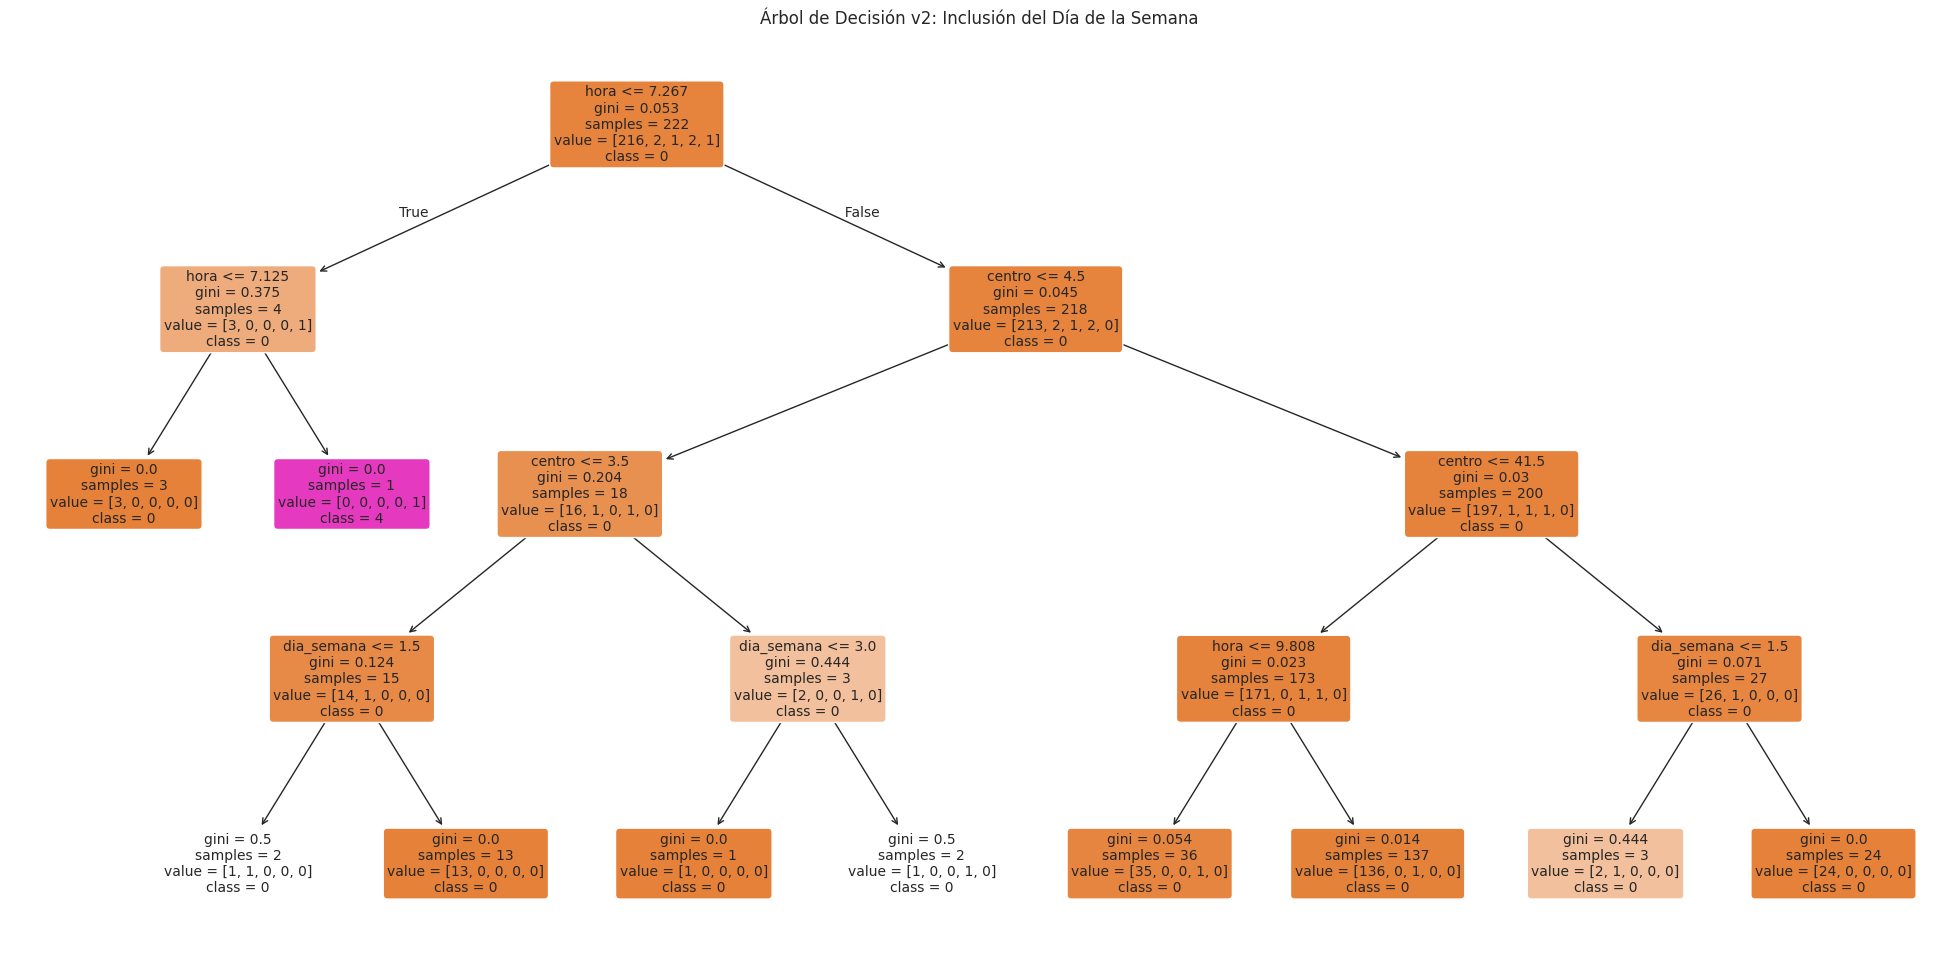

In [22]:
plt.figure(figsize=(25, 12))

plot_tree(modelo_v2,
          feature_names=['zona', 'lancha', 'centro', 'hora', 'dia_semana'],
          class_names=[str(i) for i in sorted(df['gravedad'].unique())],
          filled=True,
          rounded=True,
          fontsize=10)

plt.title("Árbol de Decisión v2: Inclusión del Día de la Semana")
plt.show()

# Ranking de importancia: ver que pesa mas ahora

/tmp/ipykernel_10895/562195109.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importancias, x='Importancia', y='Variable', palette='magma')


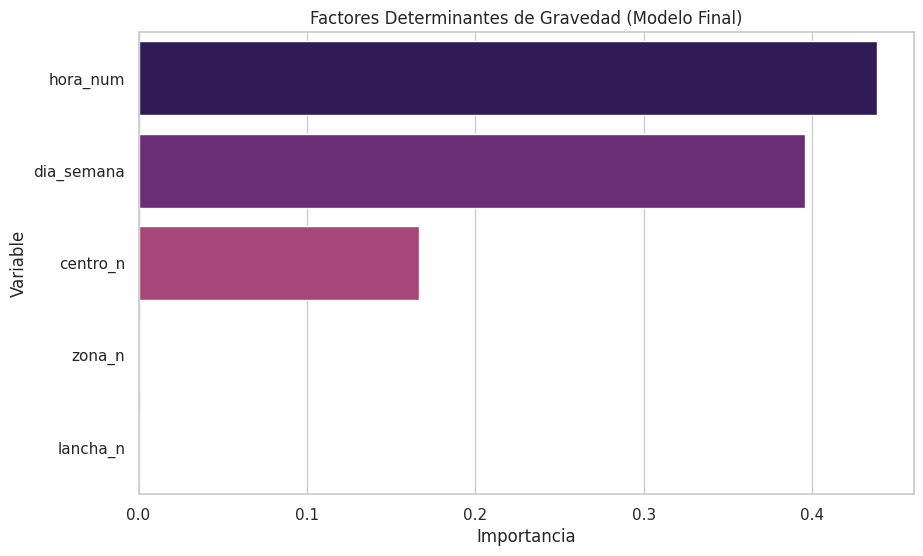

In [23]:
importancias = pd.DataFrame({'Variable': X.columns, 'Importancia': modelo_v2.feature_importances_})
importancias = importancias.sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importancias, x='Importancia', y='Variable', palette='magma')
plt.title('Factores Determinantes de Gravedad (Modelo Final)')
plt.show()

# Función de predicción de riesgo (v2)

In [28]:
import joblib
import pandas as pd

def predecir_viaje(dia_nombre, hora_reloj, zona, lancha, centro):
    """
    dia_nombre: 'Monday', 'Tuesday', etc.
    hora_reloj: Hora en formato decimal (ej: 14.5 para las 14:30)
    """
    # 1. Cargar el modelo y los codificadores guardados

    # FIX: Save the model and encoders first if they haven't been saved already.
    # This block should ideally be run once after model training, not every time the function is called.
    # However, to fix the FileNotFoundError within this cell as requested, we'll ensure the file exists.
    # The variables modelo_v2, le_zona, le_lancha, le_centro are available from previous cells.
    try:
        # Attempt to load first to see if it exists
        data = joblib.load('modelo_logistica_v2.pkl')
    except FileNotFoundError:
        # If not found, save it.
        # Ensure 'modelo_v2', 'le_zona', 'le_lancha', 'le_centro' are defined in the global scope
        # from previous cell execution.
        data_to_save = {
            'modelo': modelo_v2,
            'le_zona': le_zona,
            'le_lancha': le_lancha,
            'le_centro': le_centro
        }
        joblib.dump(data_to_save, 'modelo_logistica_v2.pkl')
        data = data_to_save # Use the just-saved data
        print("Model and encoders saved as 'modelo_logistica_v2.pkl'.")

    model = data['modelo']
    le_z = data['le_zona']
    le_l = data['le_lancha']
    le_c = data['le_centro']

    # 2. Mapeo de días a números (Lunes=0, Domingo=6)
    dias = {'Monday':0, 'Tuesday':1, 'Wednesday':2, 'Thursday':3, 'Friday':4, 'Saturday':5, 'Sunday':6}
    d_n = dias.get(dia_nombre.capitalize(), 0)

    # 3. Transformar entradas de texto a los números que entiende el modelo
    try:
        z_n = le_z.transform([zona.lower().strip()])[0]
        l_n = le_l.transform([lancha.lower().strip()])[0]
        c_n = le_c.transform([centro.lower().strip()])[0]

        # Prepare the input for prediction as a DataFrame with feature names
        # The 'X' variable with feature names is available from a previous cell.
        input_data = pd.DataFrame([[z_n, l_n, c_n, hora_reloj, d_n]], columns=X.columns)

        # 4. Realizar la predicción
        pred = model.predict(input_data)[0]

        # 5. Traducir el resultado
        niveles = {0: "✅ TODO OK", 1: "🟢 RIESGO MUY BAJO", 2: "🟡 RIESGO BAJO",
                   3: "🟠 RIESGO MEDIO", 4: "🔴 RIESGO ALTO", 5: "💀 RIESGO CRÍTICO"}

        return f"Resultado para {centro} ({lancha}): {niveles.get(pred)}"

    except ValueError as e:
        return f"Error: Uno de los datos (zona, lancha o centro) no existe en el historial."

# --- EJEMPLO DE USO ---
# ¿Qué riesgo hay mañana lunes a las 16:00 en Pangal 3 con la Sol Pacífico?
print(predecir_viaje('Monday', 16.0, 'puerto cisnes', 'sol pacifico', 'pangal 3'))

Resultado para pangal 3 (sol pacifico): ✅ TODO OK


/tmp/ipykernel_10895/3000022261.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importancias, x='Importancia', y='Atributo', palette='plasma')


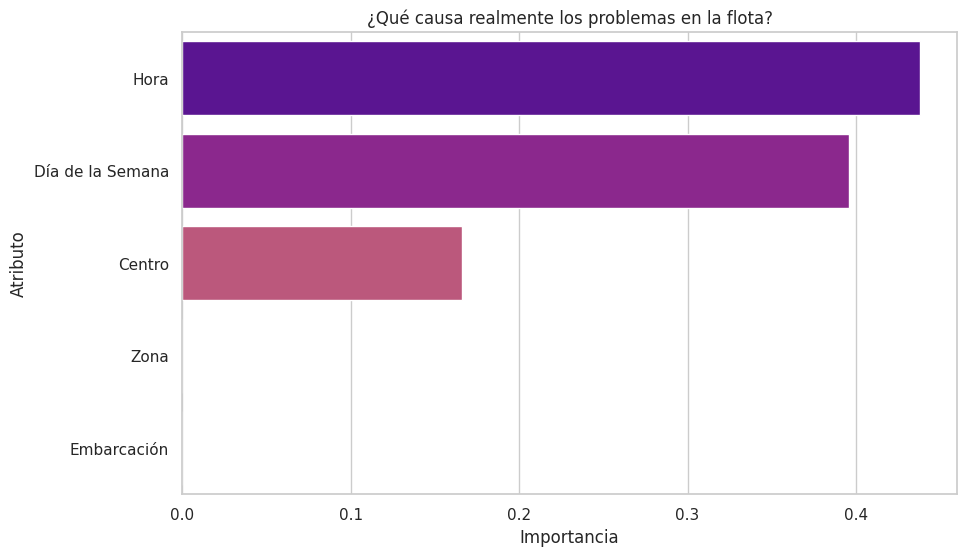

In [29]:
importancias = pd.DataFrame({
    'Atributo': ['Zona', 'Embarcación', 'Centro', 'Hora', 'Día de la Semana'],
    'Importancia': modelo_v2.feature_importances_
}).sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importancias, x='Importancia', y='Atributo', hue='Atributo', palette='plasma', legend=False)
plt.title('¿Qué causa realmente los problemas en la flota?')
plt.show()

In [ ]:
import joblib
import pandas as pd

def ejecutar_asistente():
    print("🚢 --- ASISTENTE PREDICTIVO DE DESPACHO 'ALDEN' --- 🚢")
    print("Ingrese los datos del próximo viaje para evaluar el riesgo:\n")

    try:
        # 1. Cargar el cerebro del proyecto
        data = joblib.load('modelo_logistica_v2.pkl')
        model = data['modelo']
        le_z = data['le_zona']
        le_l = data['le_lancha']
        le_c = data['le_centro']

        # 2. Captura de datos por el usuario
        dia = input("📅 Día (ej: Monday, Tuesday...): ").capitalize().strip()
        hora_input = input("⏰ Hora de llegada aproximada (ej: 14:30): ")
        zona = input("📍 Zona (melinka / puerto cisnes): ").lower().strip()
        lancha = input("🚤 Embarcación (sol pacifico / costa pacifico): ").lower().strip()
        centro = input("⚓ Centro de destino: ").lower().strip()

        # 3. Procesamiento de la hora
        h, m = map(int, hora_input.split(':'))
        hora_decimal = h + (m / 60)

        # 4. Procesamiento del día
        dias_map = {'Monday':0, 'Tuesday':1, 'Wednesday':2, 'Thursday':3, 'Friday':4, 'Saturday':5, 'Sunday':6}
        d_n = dias_map.get(dia, 0)

        # 5. Transformación y Predicción
        z_n = le_z.transform([zona])[0]
        l_n = le_l.transform([lancha])[0]
        c_n = le_c.transform([centro])[0]

        pred = model.predict([[z_n, l_n, c_n, hora_decimal, d_n]])[0]

        # 6. Salida con estilo
        niveles = {
            0: "✅ TODO OK: Históricamente no hay problemas en esta configuración.",
            1: "🟢 RIESGO MUY BAJO: Operación segura.",
            2: "🟡 RIESGO BAJO: Estar atento a detalles menores.",
            3: "🟠 RIESGO MEDIO: Se recomienda supervisar la estiba.",
            4: "🔴 RIESGO ALTO: Alta probabilidad de incidentes o retrasos.",
            5: "💀 RIESGO CRÍTICO: ¡Atención! Configuración históricamente problemática."
        }

        print("\n" + "="*50)
        print(f"🔍 DIAGNÓSTICO: {niveles.get(pred)}")
        print("="*50)

    except Exception as e:
        print(f"\n❌ Error: No se pudo realizar la predicción. Asegúrese de que el Centro '{centro}' o la Lancha existen en su base de datos.")

# Ejecutar la aplicación
if __name__ == "__main__":
    ejecutar_asistente()

🚢 --- ASISTENTE PREDICTIVO DE DESPACHO 'ALDEN' --- 🚢
Ingrese los datos del próximo viaje para evaluar el riesgo:

